# 15 — Managing layers

Every drawing call on a `Map` registers a **layer**: a named, inspectable description of what was drawn and how.
Once a figure exists you can list its layers, read one back, hide it, reorder it, swap its description, remove
it, or hand the whole figure over as plain data and rebuild it later.

This is what separates a `Map` from a pile of matplotlib calls. A script that draws and saves does not need it;
anything that *edits* a figure — a dashboard, a layer switcher, a report regenerated with one layer swapped —
depends on it entirely.

By the end you will be able to name layers, inspect them, control visibility and draw order, replace and remove
them, register an artist you built yourself, and round-trip a whole figure through its description.

API: [`Scene`](../reference/static_scene.md), [`Map`](../reference/static_map.md).

**Setup** — inline figures and the one path to the bundled example data.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits two levels up: docs/examples -> repo root.
DATA = Path("../../examples/data")


## The data

A Lisbon elevation raster and the Rhine gauge network — two different kinds of layer on one figure is enough to
show ordering and visibility properly.

In [2]:
dem = Dataset.read_file(str(DATA / "LisbonElevation.tif"))
gauges = FeatureCollection.read_file(str(DATA / "rhine_gauges.geojson"))
print(f"raster {dem.rows}x{dem.columns} EPSG:{dem.epsg}   |   {len(gauges)} gauges")

raster 421x547 EPSG:4326   |   34 gauges


C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\dev\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


## Layers have names, and you should choose them

Every call takes `name=`. Without it an id is generated from the kind (`raster-1`, `points-1`, …), which is fine
for a throwaway figure and a liability for anything you intend to edit later — you cannot address a layer whose
name you did not choose.

layer ids: ['elevation', 'isolines']


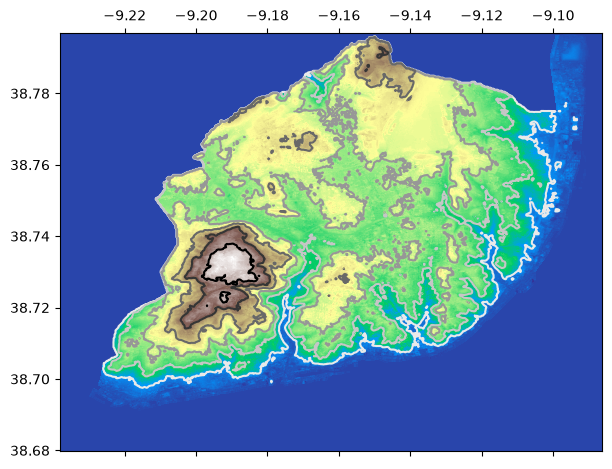

In [3]:
m = Map(crs=dem.epsg, figsize=(7, 6))
m.field(dem, name="elevation", cmap="terrain")
m.contours(dem, name="isolines", cmap="Greys", levels=8)
print("layer ids:", m.layer_ids)
m.fig;

`layer_ids` is the figure's table of contents, in draw order. Those two strings are the handles every method
below takes.

## Reading a layer back

Two different questions, two different accessors:

| accessor | returns | use it to |
|---|---|---|
| `get_layer(id)` | a `LayerSpec` — the **description** | ask what was drawn, and how |
| `artist(id)` | the matplotlib **artist** | reach the drawn object itself |

Prefer `artist(id)` over digging into private renderer state; it is the supported way in.

In [4]:
spec = m.get_layer("elevation")
print("kind:      ", spec.kind)
print("label:     ", spec.label)
print("visible:   ", spec.visible)
print("symbology: ", spec.symbology)
print("artist:    ", type(m.artist("elevation")).__name__)

kind:       raster
label:      elevation
visible:    True
symbology:  Symbology(encodings={'color': Encoding(channel='color', value=None, field='Band_1', scale=Scale(vmin=-6.82943868637085, vmax=217.9407501220703, scheme=None, breaks=(), categories=(), missing=None, over=None, under=None), output_range=None, guide=None)}, props={'via': 'imshow', 'band': 1, 'cmap': 'terrain', 'levels': None, 'interval': None, 'add_colorbar': False, 'default_cmap': 'viridis', 'zorder': None})
artist:     AxesImage


The `LayerSpec` is a frozen description — data, not a live handle. That is what makes it safe to store, compare
and serialise, and it is the basis of the round-trip at the end of this notebook.

## Showing and hiding — `set_visible`

`set_visible(id, False)` hides a layer **and records it as hidden**, so anything reading the figure's description
agrees with what is on screen. That consistency is the whole point: a layer switcher built on `figure_spec` would
otherwise drift out of step with the axes.

In [5]:
m.set_visible("isolines", False)
print("isolines visible:", m.get_layer("isolines").visible)
m.fig;

isolines visible: False


The contour lines are gone and the description says so. Putting them back is the same call with `True`.

In [6]:
m.set_visible("isolines", True)
print("isolines visible:", m.get_layer("isolines").visible)

isolines visible: True


## Draw order — `move_layer`

Layers paint in list order, so the last one drawn sits on top. `move_layer(id, index)` moves one to a new
position. Build a two-layer point figure where the order visibly matters.

before: ['all', 'rhein']


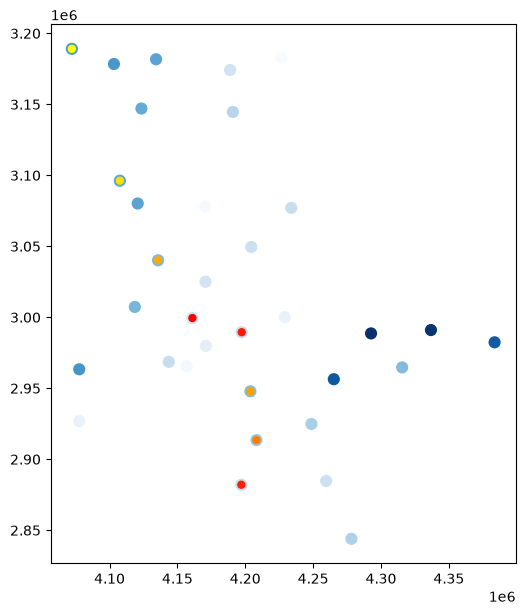

In [7]:
pts = Map(crs=gauges.crs.to_epsg(), figsize=(6, 7))
pts.points(gauges, name="all", size=60, cmap="Blues")
pts.points(gauges[gauges["river"] == "RHEIN"], name="rhein", size=25, cmap="autumn")
print("before:", pts.layer_ids)
pts.fig;

In [8]:
pts.move_layer("rhein", 0)
print("after: ", pts.layer_ids)
pts.fig;

after:  ['rhein', 'all']


With `rhein` moved to position 0 it paints first, so the larger `all` markers now cover the smaller Rhine ones.
Reordering is how you fix a layer that was drawn in the wrong sequence without rebuilding the figure.

## Swapping a description — `replace_layer`

`replace_layer` takes a whole `LayerSpec` and swaps it in, **keeping the layer's id and its place in draw
order**. Because the spec is a frozen dataclass, the idiomatic way to make the new one is
`dataclasses.replace`.

In [9]:
import dataclasses

relabelled = dataclasses.replace(m.get_layer("elevation"), label="Elevation (m)")
m.replace_layer(relabelled)
print("label is now:", m.get_layer("elevation").label)
print("ids unchanged:", m.layer_ids)

label is now: Elevation (m)
ids unchanged: ['elevation', 'isolines']


Same id, same position, new description. This is the mechanism behind "change the colour ramp and redraw"
without disturbing anything else on the figure.

## Removing — `remove_layer`

`remove_layer(id)` takes the layer off the figure entirely: gone from `layer_ids`, gone from the axes.

In [10]:
m.remove_layer("isolines")
print("ids after removal:", m.layer_ids)
m.fig;

ids after removal:

 ['elevation']


## Registering your own artist — `add_layer`

Sometimes you need a matplotlib call the layer API does not wrap. `add_layer` lets you draw it yourself on
`map.ax` and then **register it as a layer**, so it gains an id and takes part in visibility and ordering like
any other.

ids: ['flight-track', 'coastlines-1']


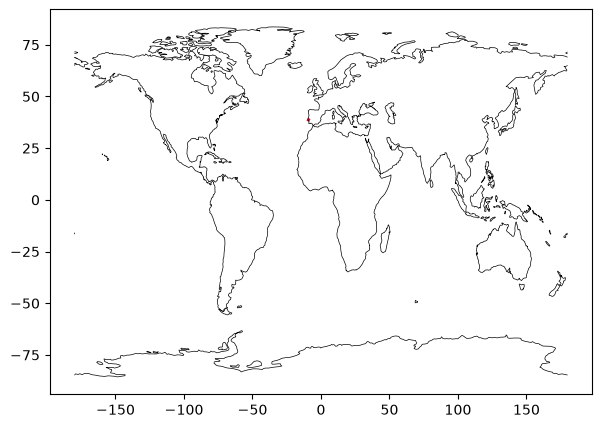

In [11]:
own = Map(crs=4326, figsize=(7, 5))
own.coastlines()
(track,) = own.ax.plot([-9.2, -9.1, -9.0], [38.6, 38.7, 38.8], color="crimson", linewidth=2)
own.add_layer(track, name="flight-track")
print("ids:", own.layer_ids)
own.fig;

The hand-drawn line is now a first-class layer — `set_visible("flight-track", False)` works on it. Use this as
the escape hatch, not the habit: a registered artist carries no source description, so it cannot be redrawn from
`figure_spec` the way a `field` or `points` layer can.

## The figure as data — `figure_spec` and `from_figure`

`figure_spec` hands back the **whole scene as a value**: its layers, their sources and the view. `Map.from_figure`
takes one back and builds the figure again. That round trip is how a figure travels between processes, gets
stored in a database, or is diffed between two runs.

In [12]:
spec = m.figure_spec
print("layers:", [layer.id for layer in spec.layers])
print("view:  ", spec.view if hasattr(spec, "view") else m.viewport)

layers: ['elevation']
view:   Viewport(crs=4326, bounds=None, domain=None, globe=False, center=None, zoom=None)


rebuilt ids: ['elevation']


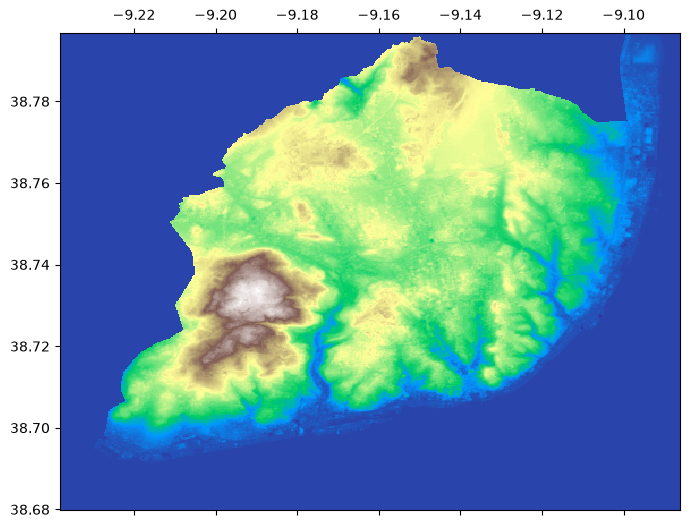

In [13]:
rebuilt = Map.from_figure(spec)
print("rebuilt ids:", rebuilt.layer_ids)
rebuilt.fig;

The rebuilt figure carries the same layers as the original. Note what had to be true for this to work: each
layer's source has to be something the description can name. That is why a path-backed layer round-trips and an
`add_layer` artist does not.

## Reacting to a click — `on_pick`

`on_pick(callback)` registers a function called when the reader clicks a layer. The callback receives a `Pick`:

| field | meaning |
|---|---|
| `layer_id` | which layer was hit |
| `x`, `y` | where the click landed, in display-CRS coordinates |
| `hits` | the indices within the layer that were hit |
| `event` | the underlying matplotlib pick event |

Picking needs a **live GUI backend** to fire, so it does nothing in a saved notebook — the cell below registers
the handler and shows what it would receive. Run it under `%matplotlib widget` to click for real.

handler registered; clicks are delivered under an interactive backend


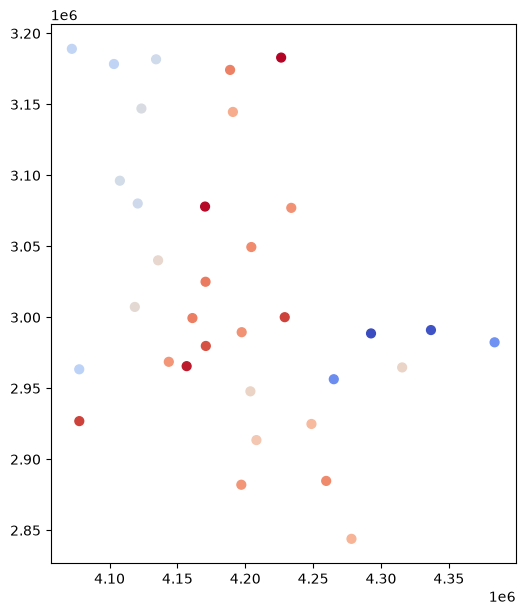

In [14]:
clicked = []

def report(pick):
    clicked.append(pick)
    print(f"clicked layer {pick.layer_id!r} at ({pick.x:.0f}, {pick.y:.0f}), hits={pick.hits}")

picker = Map(crs=gauges.crs.to_epsg(), figsize=(6, 7))
picker.points(gauges, name="gauges", size=40)
picker.on_pick(report)
print("handler registered; clicks are delivered under an interactive backend")
picker.fig;

## Takeaway

- Pass `name=` to every layer you might want to address later; generated ids are for throwaway figures.
- `get_layer(id)` gives the **description**, `artist(id)` the **matplotlib object**.
- `set_visible`, `move_layer`, `replace_layer`, `remove_layer` all edit a live figure by id.
- `add_layer` registers an artist you drew yourself — the escape hatch for anything the API does not wrap.
- `figure_spec` / `Map.from_figure` turn a scene into data and back, which is what makes figures storable.
- `on_pick` delivers clicks as a `Pick`, under an interactive backend.

Next: [`16_framing_and_insets`](16_framing_and_insets.ipynb) — controlling what the map is looking at.